In [5]:
import pandas as pd
df=pd.read_csv("train.csv")



In [6]:
df

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,593989,23004.26,0.152,703,20958.37,10.92,Female,Single,High School,Employed,Business,C3,1.0
593990,593990,35289.43,0.105,559,3257.24,14.62,Male,Single,Bachelor's,Employed,Debt consolidation,F5,1.0
593991,593991,47112.64,0.072,675,929.27,14.13,Female,Married,Bachelor's,Employed,Debt consolidation,C1,1.0
593992,593992,76748.44,0.067,740,16290.40,9.87,Male,Single,Bachelor's,Employed,Debt consolidation,B2,1.0


# Feature Engineering

In [7]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

ordinal_cols = ["grade_subgrade", "loan_purpose", "employment_status", "education_level"]
one_hot_cols = ["gender", "marital_status"]

# Define encoders
one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ordinal = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

# Fit + transform
one_hot_arr = one_hot.fit_transform(df[one_hot_cols])
ordinal_arr = ordinal.fit_transform(df[ordinal_cols])

# Convert to DataFrames (keep index!)
one_hot_df = pd.DataFrame(
    one_hot_arr, 
    columns=one_hot.get_feature_names_out(one_hot_cols),
    index=df.index
)

ordinal_df = pd.DataFrame(
    ordinal_arr,
    columns=ordinal_cols,
    index=df.index
)

# Drop original categorical cols and concat encoded ones
df = pd.concat(
    [
        df.drop(one_hot_cols + ordinal_cols, axis=1),
        ordinal_df,
        one_hot_df
    ],
    axis=1
)



df["loan_to_income"] = df["loan_amount"] / df["annual_income"]
df["total_debt_est"] = (df["annual_income"] * df["debt_to_income_ratio"]) / 100
df["loan_to_total_debt"] = df["loan_amount"] / (df["total_debt_est"] + 1e-6)



In [8]:
df.columns

Index(['id', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 'loan_paid_back', 'grade_subgrade',
       'loan_purpose', 'employment_status', 'education_level', 'gender_Female',
       'gender_Male', 'gender_Other', 'marital_status_Divorced',
       'marital_status_Married', 'marital_status_Single',
       'marital_status_Widowed', 'loan_to_income', 'total_debt_est',
       'loan_to_total_debt'],
      dtype='object')

In [9]:
from sklearn.model_selection import train_test_split
del df["id"]
df_train, df_val = train_test_split(df, test_size=0.2, random_state=1)

df_train=df_train.reset_index(drop=True)
df_val=df_val.reset_index(drop=True)

y_train=df_train.loan_paid_back
y_val=df_val.loan_paid_back

del df_train["loan_paid_back"]
del df_val["loan_paid_back"]


# Identify outliers

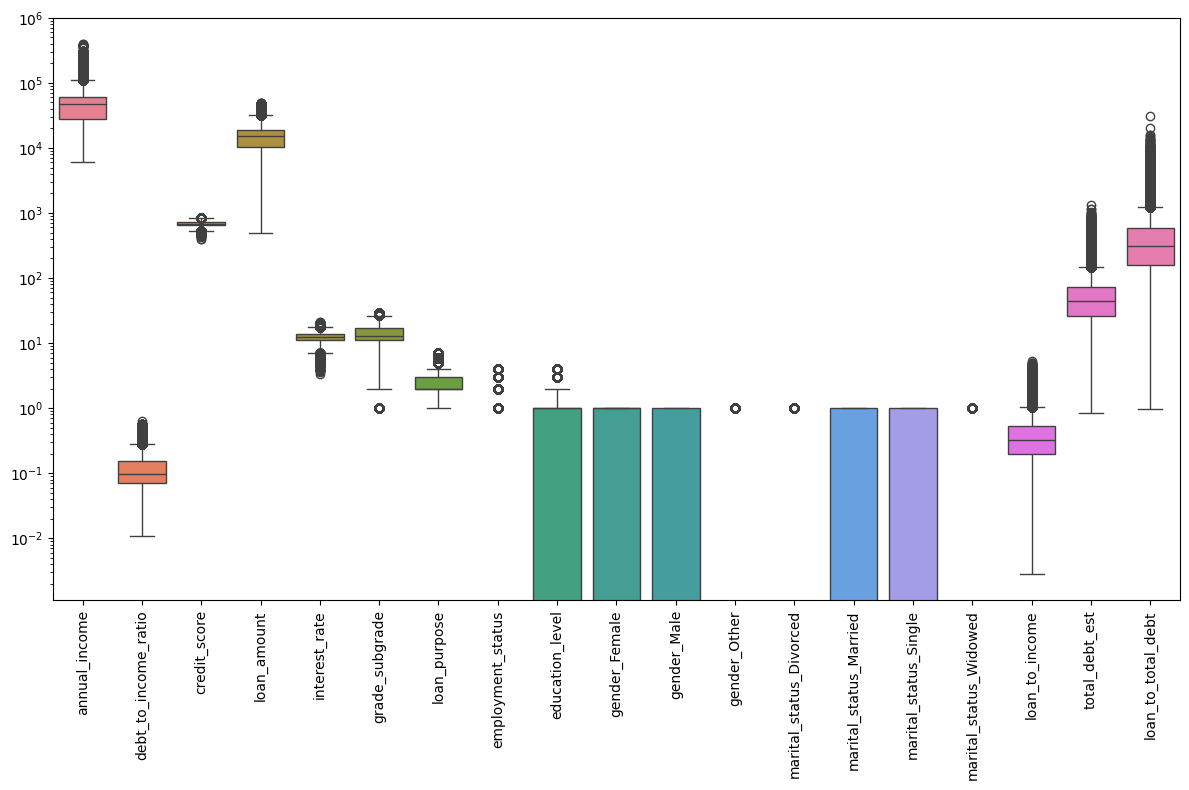

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
ax = sns.boxplot(data=df_train)

ax.set_yscale('log')   # escala log no eixo y

plt.xticks(rotation=90)
plt.title('')
plt.tight_layout()
plt.show()


# EDA

In [11]:
df_train.isna().sum()

annual_income              0
debt_to_income_ratio       0
credit_score               0
loan_amount                0
interest_rate              0
grade_subgrade             0
loan_purpose               0
employment_status          0
education_level            0
gender_Female              0
gender_Male                0
gender_Other               0
marital_status_Divorced    0
marital_status_Married     0
marital_status_Single      0
marital_status_Widowed     0
loan_to_income             0
total_debt_est             0
loan_to_total_debt         0
dtype: int64

In [12]:
df_train.describe()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,grade_subgrade,loan_purpose,employment_status,education_level,gender_Female,gender_Male,gender_Other,marital_status_Divorced,marital_status_Married,marital_status_Single,marital_status_Widowed,loan_to_income,total_debt_est,loan_to_total_debt
count,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000
mean,48207.471032,0.120667,680.949791,15021.937942,12.357039,13.965073,2.610082,0.684544,0.831684,0.514995,0.478776,0.006229,0.035846,0.466409,0.486647,0.011099,0.427807,58.181427,473.252200
std,26700.214901,0.068535,55.409807,6933.189795,2.008837,5.114906,1.657732,1.331604,0.973053,0.499776,0.499550,0.078678,0.185907,0.498871,0.499822,0.104764,0.366755,49.783341,543.667280
min,6002.430000,0.011000,395.000000,500.090000,3.320000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002835,0.841754,0.970604
25%,27920.690000,0.072000,646.000000,10279.440000,10.990000,11.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.194614,25.920516,160.064415
50%,46603.520000,0.096000,682.000000,15000.220000,12.370000,13.000000,2.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.322355,44.107119,311.677483
75%,60981.320000,0.156000,719.000000,18865.645000,13.680000,17.000000,3.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.537334,73.838621,582.935837
max,393381.740000,0.627000,849.000000,48954.700000,20.990000,29.000000,7.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.361253,1338.169664,30409.986616


# Target plot

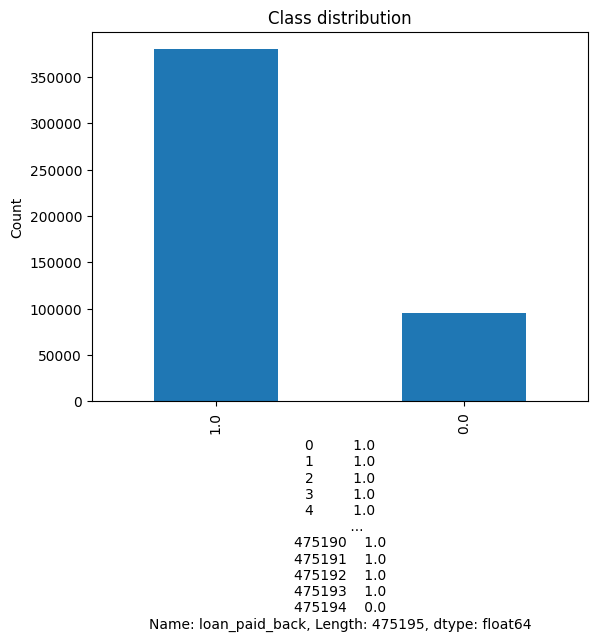

In [13]:
import matplotlib.pyplot as plt

y_train.value_counts().plot(kind="bar")
plt.xlabel(y_train)
plt.ylabel("Count")
plt.title("Class distribution")
plt.show()


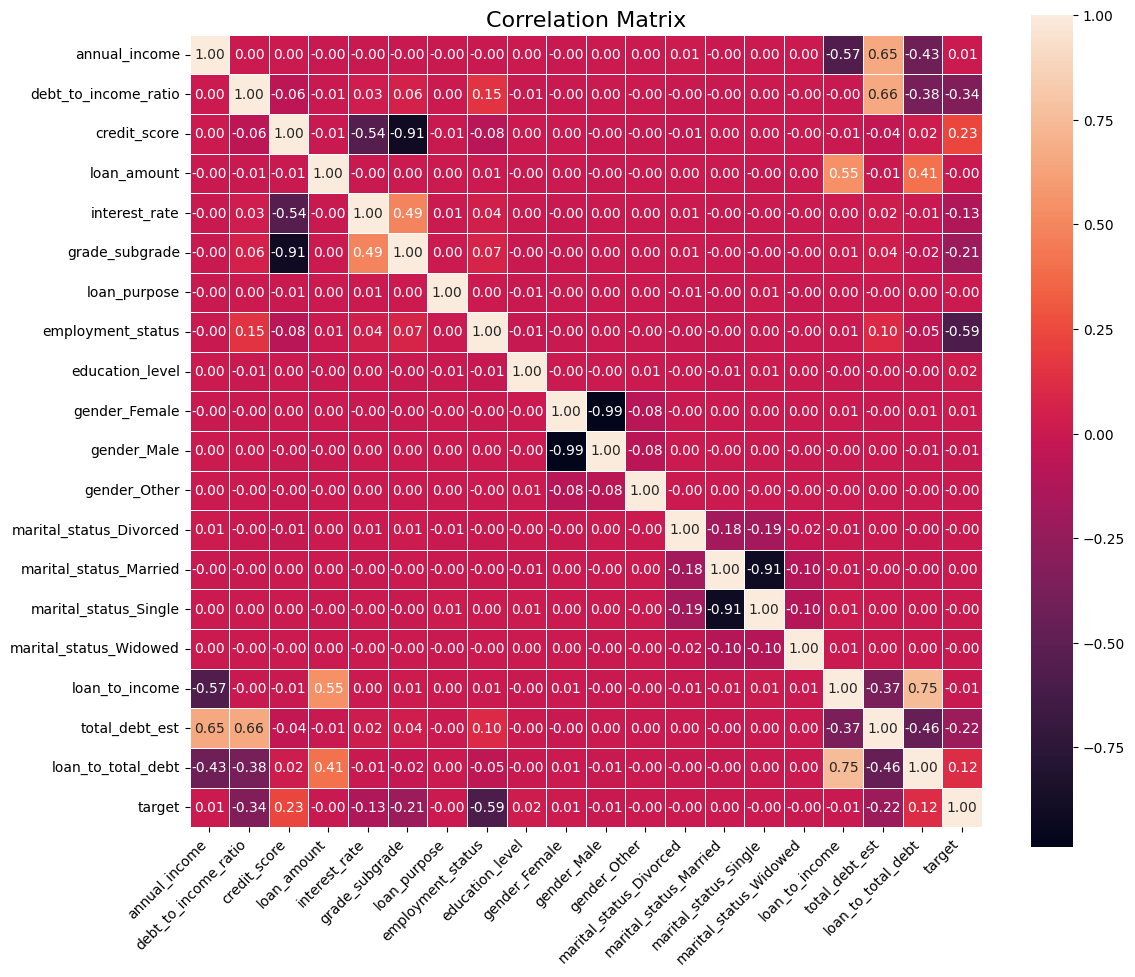

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd   # only if not imported yet

# Combine X and y into one DataFrame
df_corr = pd.concat(
    [df_train, y_train.rename("target")],  # rename target column if needed
    axis=1
)

# Correlation matrix (numeric columns only)
corr = df_corr.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [15]:
from sklearn.metrics import mutual_info_score

def mutual_info_loan_paid_back(series):
    return mutual_info_score(series,df_corr.target)

mi = df_corr.apply(mutual_info_loan_paid_back)
mi.sort_values(ascending=False)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.1

target                     5.018199e-01
loan_to_total_debt         5.018082e-01
loan_to_income             5.004306e-01
total_debt_est             4.692042e-01
employment_status          1.759167e-01
annual_income              1.223210e-01
loan_amount                1.191959e-01
debt_to_income_ratio       7.969565e-02
credit_score               3.370546e-02
grade_subgrade             2.674850e-02
interest_rate              1.307710e-02
loan_purpose               3.245419e-04
education_level            3.113894e-04
gender_Female              2.630371e-05
gender_Male                2.602354e-05
marital_status_Widowed     3.203553e-06
marital_status_Married     2.963546e-07
marital_status_Divorced    1.713792e-07
gender_Other               3.498074e-08
marital_status_Single      1.418256e-10
dtype: float64

# UnderSampling

In [16]:
from imblearn.under_sampling import RandomUnderSampler

print("Class distribution BEFORE undersampling (train):")
print(y_train.value_counts())
print()

# 1) Descobrir classes
class_counts = y_train.value_counts()
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

n_minority = class_counts[minority_class]

# 2) Escolher a razão desejada majority/minority
#    Exemplo: majority = 2x minority
majority_ratio = 2.5
n_majority_new = int(n_minority * majority_ratio)

print(f"Minority class ({minority_class}) count: {n_minority}")
print(f"Majority class ({majority_class}) new count (target): {n_majority_new}")
print()

# 3) Definir estratégia de undersampling
sampling_strategy = {
    majority_class: n_majority_new,
    minority_class: n_minority
}

rus = RandomUnderSampler(
    sampling_strategy=sampling_strategy,
    random_state=42
)

df_train_res, y_train_res = rus.fit_resample(df_train, y_train)

# 4) Sobrescrever os nomes originais
df_train_under_sample = df_train_res
y_train_under_sample  = y_train_res

print("Class distribution AFTER undersampling (train):")
print(y_train_under_sample.value_counts())

from sklearn.feature_extraction import DictVectorizer

dv = DictVectorizer(sparse=False)

train_dict_under = df_train_under_sample.to_dict(orient='records')
X_train_under = dv.fit_transform(train_dict_under)

val_dict_under = df_val.to_dict(orient='records')
X_val_under = dv.transform(val_dict_under)


Class distribution BEFORE undersampling (train):
loan_paid_back
1.0    379669
0.0     95526
Name: count, dtype: int64

Minority class (0.0) count: 95526
Majority class (1.0) new count (target): 238815

Class distribution AFTER undersampling (train):
loan_paid_back
1.0    238815
0.0     95526
Name: count, dtype: int64


# Model training


In [17]:
from sklearn.feature_extraction import DictVectorizer

dv = DictVectorizer(sparse=False)

train_dict = df_train.to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val.to_dict(orient='records')
X_val = dv.transform(val_dict)


In [18]:
df_train

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,grade_subgrade,loan_purpose,employment_status,education_level,gender_Female,gender_Male,gender_Other,marital_status_Divorced,marital_status_Married,marital_status_Single,marital_status_Widowed,loan_to_income,total_debt_est,loan_to_total_debt
0,47868.15,0.070,773,28644.19,10.16,6.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.598398,33.507705,854.853806
1,35444.49,0.153,693,27775.31,16.14,14.0,2.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.783628,54.230070,512.175434
2,92914.49,0.140,715,30784.02,12.35,13.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.331316,130.080286,236.653998
3,43761.69,0.156,723,8181.09,10.13,13.0,6.0,0.0,4.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.186946,68.268236,119.837428
4,63671.48,0.149,675,17626.06,12.60,12.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.276828,94.870505,185.790724
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475190,51957.35,0.086,681,12452.00,14.96,13.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.239658,44.683321,278.672208
475191,20264.17,0.160,652,18207.08,12.17,18.0,2.0,2.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.898486,32.422672,561.553947
475192,25609.70,0.053,664,1418.39,12.66,18.0,2.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.055385,13.573141,104.499754
475193,39711.94,0.262,638,9121.82,11.20,17.0,4.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.229700,104.045283,87.671634


# Mlp Classifier

In [19]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Alguns setups para testar (podes ajustar)
configs = [
    {"hidden_layer_sizes": (32,),     "alpha": 1e-4, "learning_rate_init": 1e-3},
    {"hidden_layer_sizes": (64,),     "alpha": 1e-4, "learning_rate_init": 1e-3},
    {"hidden_layer_sizes": (64, 32),  "alpha": 1e-4, "learning_rate_init": 1e-3},
    {"hidden_layer_sizes": (128, 64), "alpha": 1e-4, "learning_rate_init": 1e-3},
    {"hidden_layer_sizes": (64, 64),  "alpha": 1e-3, "learning_rate_init": 5e-4},
]

print("Neural Network (MLPClassifier)\n")

# Escala 1x (igual para todos os modelos) — mais correto e mais rápido
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

for cfg in configs:
    model = MLPClassifier(
        hidden_layer_sizes=cfg["hidden_layer_sizes"],
        activation="relu",
        solver="adam",
        alpha=cfg["alpha"],                 # L2 regularization
        learning_rate_init=cfg["learning_rate_init"],
        max_iter=1000,
        early_stopping=True,                # usa parte do treino internamente
        n_iter_no_change=20,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)

    acc  = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec  = recall_score(y_val, y_pred, zero_division=0)
    f1   = f1_score(y_val, y_pred, zero_division=0)

    print(f"Config = {cfg}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-score : {f1:.4f}")
    print("-" * 40)


Neural Network (MLPClassifier)

Config = {'hidden_layer_sizes': (32,), 'alpha': 0.0001, 'learning_rate_init': 0.001}
  Accuracy : 0.9014
  Precision: 0.9045
  Recall   : 0.9800
  F1-score : 0.9407
----------------------------------------
Config = {'hidden_layer_sizes': (64,), 'alpha': 0.0001, 'learning_rate_init': 0.001}
  Accuracy : 0.9014
  Precision: 0.9042
  Recall   : 0.9803
  F1-score : 0.9407
----------------------------------------
Config = {'hidden_layer_sizes': (64, 32), 'alpha': 0.0001, 'learning_rate_init': 0.001}
  Accuracy : 0.9013
  Precision: 0.9001
  Recall   : 0.9858
  F1-score : 0.9410
----------------------------------------
Config = {'hidden_layer_sizes': (128, 64), 'alpha': 0.0001, 'learning_rate_init': 0.001}
  Accuracy : 0.9010
  Precision: 0.9053
  Recall   : 0.9783
  F1-score : 0.9404
----------------------------------------
Config = {'hidden_layer_sizes': (64, 64), 'alpha': 0.001, 'learning_rate_init': 0.0005}
  Accuracy : 0.9015
  Precision: 0.9037
  Recall 

# Neural Network (Keras) w/ extra layer + dropout


In [28]:
import os
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ---------------------------
# FORCE GPU (tem de vir antes de criar/treinar modelos)
# ---------------------------
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # escolhe a GPU 0

print("TF version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices("GPU")))
print("GPUs:", tf.config.list_physical_devices("GPU"))

gpus = tf.config.list_physical_devices("GPU")


# 1) Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled   = scaler.transform(X_val).astype(np.float32)

# 2) Configs
configs = [
    {"units": (128, 64, 32), "dropout": 0.2, "lr": 1e-3},
    {"units": (128, 64, 32), "dropout": 0.4, "lr": 1e-3},
    {"units": (256, 128, 64), "dropout": 0.3, "lr": 5e-4},
]

def build_model(input_dim, units=(128, 64, 32), dropout=0.3, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(units[0], activation="relu"),
        layers.Dropout(dropout),

        layers.Dense(units[1], activation="relu"),
        layers.Dropout(dropout),

        layers.Dense(units[2], activation="relu"),
        layers.Dropout(dropout),

        # IMPORTANTE com mixed precision: output float32
        layers.Dense(1, activation="sigmoid", dtype="float32")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        jit_compile=True  # se der erro, remove esta linha
    )
    return model

for cfg in configs:
    tf.keras.utils.set_random_seed(42)

    # força GPU (se existir)
    device = "/GPU:0" if tf.config.list_physical_devices("GPU") else "/CPU:0"
    with tf.device(device):
        model = build_model(
            input_dim=X_train_scaled.shape[1],
            units=cfg["units"],
            dropout=cfg["dropout"],
            lr=cfg["lr"]
        )

        callbacks = [
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=3,
                restore_best_weights=True
            )
        ]

        model.fit(
            X_train_scaled, y_train,
            validation_data=(X_val_scaled, y_val),
            epochs=10,
            batch_size=512,   # <<< MUITO mais rápido que 8 (ajusta: 64/128/256/512)
            verbose=0,
            callbacks=callbacks
        )

    y_proba = model.predict(X_val_scaled, batch_size=1024, verbose=0).ravel()
    y_pred = (y_proba >= 0.5).astype(int)

    acc  = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec  = recall_score(y_val, y_pred, zero_division=0)
    f1   = f1_score(y_val, y_pred, zero_division=0)

    print(f"Device = {device} | Config = {cfg}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-score : {f1:.4f}")
    print("-" * 40)


TF version: 2.19.0
Num GPUs Available: 1
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Device = /GPU:0 | Config = {'units': (128, 64, 32), 'dropout': 0.2, 'lr': 0.001}
  Accuracy : 0.9014
  Precision: 0.8994
  Recall   : 0.9869
  F1-score : 0.9411
----------------------------------------
Device = /GPU:0 | Config = {'units': (128, 64, 32), 'dropout': 0.4, 'lr': 0.001}
  Accuracy : 0.9006
  Precision: 0.8970
  Recall   : 0.9890
  F1-score : 0.9408
----------------------------------------
Device = /GPU:0 | Config = {'units': (256, 128, 64), 'dropout': 0.3, 'lr': 0.0005}
  Accuracy : 0.9014
  Precision: 0.8990
  Recall   : 0.9874
  F1-score : 0.9411
----------------------------------------


# Deep MLP with BatchNorm, Dropout and L2 Regularization

In [33]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # força usar a GPU 0 (se existir)

import numpy as np
import pandas as pd
import json

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

# ---------------------------
# GPU setup
# ---------------------------
print("TF version:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)



DEVICE = "/GPU:0" if gpus else "/CPU:0"
print("Using device:", DEVICE)

# ---------------------------
# Scale
# ---------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled   = scaler.transform(X_val).astype(np.float32)

# ---------------------------
# Configs (exemplos)
# ---------------------------
configs = [
    {"units": (256, 128, 64, 32), "dropout": 0.35, "l2": 1e-4, "lr": 1e-3, "batch_size": 256},
    {"units": (128, 128, 64, 32), "dropout": 0.25, "l2": 5e-4, "lr": 8e-4, "batch_size": 256},
    {"units": (128, 64, 32, 16),  "dropout": 0.30, "l2": 1e-4, "lr": 5e-4, "batch_size": 128},
]

def build_model(input_dim, units, dropout, l2, lr):
    inp = keras.Input(shape=(input_dim,))
    x = inp

    for u in units:
        x = layers.Dense(u, use_bias=False, kernel_regularizer=regularizers.l2(l2))(x)
        x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU(negative_slope=0.1)(x)
        x = layers.Dropout(dropout)(x)

    # IMPORTANTE com mixed precision: output float32
    out = layers.Dense(1, activation="sigmoid", dtype="float32")(x)

    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        jit_compile=True  # se der erro na tua versão, remove esta linha
    )
    return model

# ---------------------------
# Tracking best model
# ---------------------------
best_auc = -1.0
best_f1 = -1.0
best_model = None
best_cfg = None

all_rows = []

for cfg in configs:
    tf.keras.utils.set_random_seed(42)

    with tf.device(DEVICE):  # <<< força GPU aqui (se existir)
        model = build_model(
            input_dim=X_train_scaled.shape[1],
            units=cfg["units"],
            dropout=cfg["dropout"],
            l2=cfg["l2"],
            lr=cfg["lr"]
        )

        callbacks = [
            keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=0),
            keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=0),
        ]

        model.fit(
            X_train_scaled, y_train,
            validation_data=(X_val_scaled, y_val),
            epochs=10,
            batch_size=cfg["batch_size"],
            verbose=0,
            callbacks=callbacks
        )

    # probs + preds (batch grande acelera predict)
    y_proba = model.predict(X_val_scaled, batch_size=2048, verbose=0).ravel()
    y_pred  = (y_proba >= 0.5).astype(int)

    # metrics
    acc  = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec  = recall_score(y_val, y_pred, zero_division=0)
    f1   = f1_score(y_val, y_pred, zero_division=0)

    # AUC (protege caso só haja 1 classe em y_val)
    try:
        val_auc = roc_auc_score(y_val, y_proba)
    except ValueError:
        val_auc = np.nan

    row = {
        **cfg,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "val_auc": val_auc,
        "device": DEVICE,
    }
    all_rows.append(row)

    # ---------------------------
    # Update best model (prioritize AUC, break ties with F1)
    # ---------------------------
    if (not np.isnan(val_auc)) and ((val_auc > best_auc) or (val_auc == best_auc and f1 > best_f1)):
        best_auc = val_auc
        best_f1 = f1
        best_model = model
        best_cfg = row.copy()

# ---------------------------
# Top configurations by AUC (showing F1 too)
# ---------------------------
results_df = pd.DataFrame(all_rows).sort_values(by=["val_auc", "f1"], ascending=False)
print("\nTop 10 configs by AUC:\n")
print(results_df.head(10))

print("\nBest configuration found:\n", best_cfg)

# ---------------------------
# Save best model config (+ optional model)
# ---------------------------
if best_model is not None:
    with open("nn_best_params.json", "w") as f:
        json.dump(best_cfg, f, indent=2, default=str)
    print("Best configuration saved to 'nn_best_params.json'")

    best_model.save("nn_best_model.keras")
    print("Best model saved to 'nn_best_model.keras'")
else:
    print("No model was trained (something went wrong).")


TF version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Using device: /GPU:0

Top 10 configs by AUC:

                units  dropout      l2      lr  batch_size  accuracy  \
1  (128, 128, 64, 32)     0.25  0.0005  0.0008         256  0.901026   
2   (128, 64, 32, 16)     0.30  0.0001  0.0005         128  0.901119   
0  (256, 128, 64, 32)     0.35  0.0001  0.0010         256  0.901228   

   precision    recall        f1   val_auc  device  
1   0.898965  0.986923  0.940893  0.909523  /GPU:0  
2   0.898402  0.987830  0.940996  0.909494  /GPU:0  
0   0.899119  0.986997  0.941011  0.909220  /GPU:0  

Best configuration found:
 {'units': (128, 128, 64, 32), 'dropout': 0.25, 'l2': 0.0005, 'lr': 0.0008, 'batch_size': 256, 'accuracy': 0.9010261029133242, 'precision': 0.898965447681623, 'recall': 0.9869232797258107, 'f1': 0.9408931874849191, 'val_auc': np.float64(0.909523370416378), 'device': '/GPU:0'}
Best configuration saved to 'nn_best_params.json'
Best mo